# Wine Style Clustering — 04: Visualisation

**Input:** `data/processed/wines_{red,white,rose}_clustered.csv`  
**Output:** `results/figures/04_*.png` — publication-ready charts

Contents:
1. UMAP — individual colour plots with labelled clusters
2. UMAP — combined overview
3. TF-IDF top descriptors per cluster
4. Cluster size comparison

---

## 0. Setup

In [36]:
import os
os.chdir(os.path.expanduser('~/Documents/wine-style-clustering'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
import warnings
warnings.filterwarnings('ignore')

os.makedirs('results/figures', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'axes.spines.left':  False,
    'axes.spines.bottom': False,
    'font.family': 'serif',
    'font.size': 11,
})

# Cluster colour palettes
RED_PALETTE   = ['#C1392B', '#2980B9', '#27AE60', '#F39C12', '#8E44AD', '#16A085']
WHITE_PALETTE = ['#2C3E50', '#E67E22', '#2980B9', '#27AE60', '#8E44AD', '#C0392B']
ROSE_PALETTE  = ['#C0392B', '#8E44AD', '#E67E22']
NOISE_COLOR   = '#DDDDDD'

# Wine-specific stop words — generic terms that appear in all clusters
WINE_STOPWORDS = [
    'fruit', 'palate', 'finish', 'nose', 'wine', 'notes',
    'red', 'white', 'good', 'long', 'well', 'acidity',
    'tannins', 'tannin', 'flavour', 'flavours', 'flavor', 'flavors',
    'aroma', 'aromas', 'colour', 'color', 'style', 'note', 'hint',
    'touch', 'little', 'quite', 'really', 'very', 'nice', 'great',
    'fine', 'texture', 'body', 'shows', 'wine', 's',
    'drinking', 'drink', 'palate', 'mid', 'mid palate', 'gives',
    'making', 'showing', 'offer', 'offers', 'character','weight',
    'lovely', 'bright', 'bodied', 'fruits', 'ripe',
    'pinot', 'noir', 'chardonnay', 'cabernet', 'sauvignon', 'riesling', 'blanc', 'rosé', 'pink',
     # Geographic terms that leak into descriptions
    'cornas', 'gigondas', 'chablis', 'condrieu', 'village', 'clos',
    'premier', 'rhône', 'oregon', 'burgundy', 'bordeaux', 'tuscany',
    
    # Noise words
    'pressed', 'tug', 'embedded', 'blossoms', 'perfumes', 'marvellous',
    'enjoyably', 'touched', 'popcorn', 'work', 'likely', 'shade', 'cut',
    'figs', 'nib', 'buttered', 'creaminess', 'actually'
    
    # Already generic
    'fresh', 'dark', 'black', 'juicy', 'sweet',
]

STOP_WORDS = list(ENGLISH_STOP_WORDS) + WINE_STOPWORDS

print('Ready.')


Ready.


## 1. Load data

In [37]:
df_red   = pd.read_csv('data/processed/wines_red_clustered.csv')
df_white = pd.read_csv('data/processed/wines_white_clustered.csv')
df_rose  = pd.read_csv('data/processed/wines_rose_clustered.csv')

print(f'Red:   {len(df_red):,} | White: {len(df_white):,} | Rosé: {len(df_rose):,}')

RED_LABELS = {
    0: 'Firm-structured, floral reds with a savoury, earthy core',
    1: 'Silky, red-fruited aromatics with forest floor and mineral depth',
    2: 'Dark, oak-framed power reds built on cassis and graphite',
    3: 'Spice-driven dark reds, approachable and food-ready',
    4: 'Bright, juicy, light reds with crunchy red fruit',
    5: 'Fresh, mineral, well-balanced reds with honest grip',
}
WHITE_LABELS = {
    0: 'Rich, mineral-driven whites with creamy orchard depth',
    1: 'Aromatic, fruit-expressive whites across the spectrum',
    2: 'Vibrant, tropical-citrus whites with herbal freshness',
    3: 'Full-bodied, generous whites with honeyed stone fruit weight',
    4: 'Fresh, florally aromatic whites with citrus-saline drive',
    5: 'Precise, mineral-citrus whites with electric acidity',
}
ROSE_LABELS = {
    0: 'Deep, structured rosés with dark fruit and tannic grip',
    1: 'Elegant, mineral pale rosés with floral lift and stone fruit',
    2: 'Fresh, vivid rosés with wild berry and citrus-saline snap',
}

# Short labels for legend (first phrase before comma)
RED_SHORT   = {k: v.split(',')[0] for k, v in RED_LABELS.items()}
WHITE_SHORT = {k: v.split(',')[0] for k, v in WHITE_LABELS.items()}
ROSE_SHORT  = {k: v.split(',')[0] for k, v in ROSE_LABELS.items()}


Red:   8,783 | White: 8,364 | Rosé: 2,094


## 2. UMAP — individual colour plots

One publication-ready figure per colour. Noise shown as light grey.

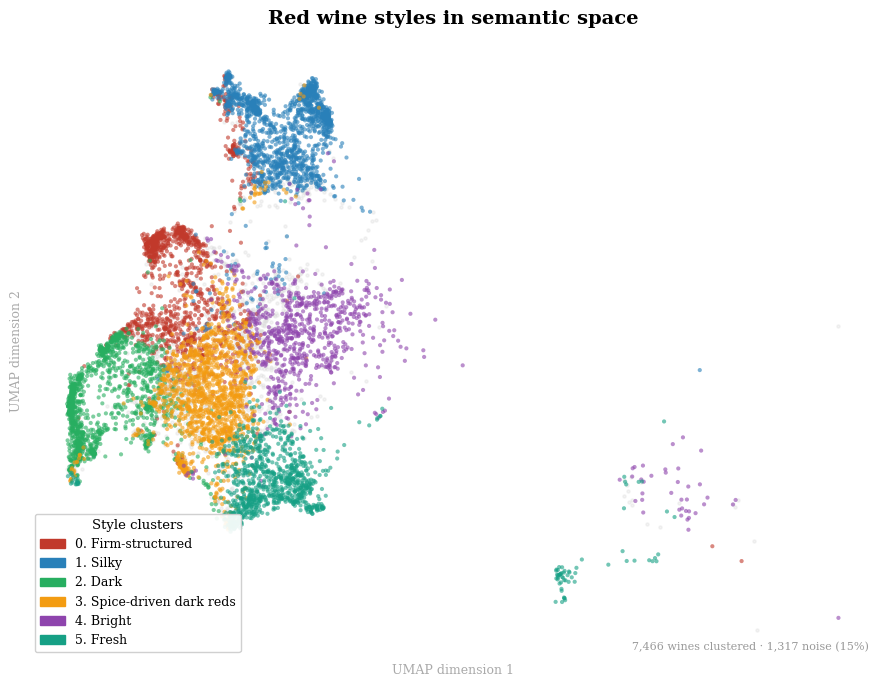

Saved: results/figures/04_umap_red.png


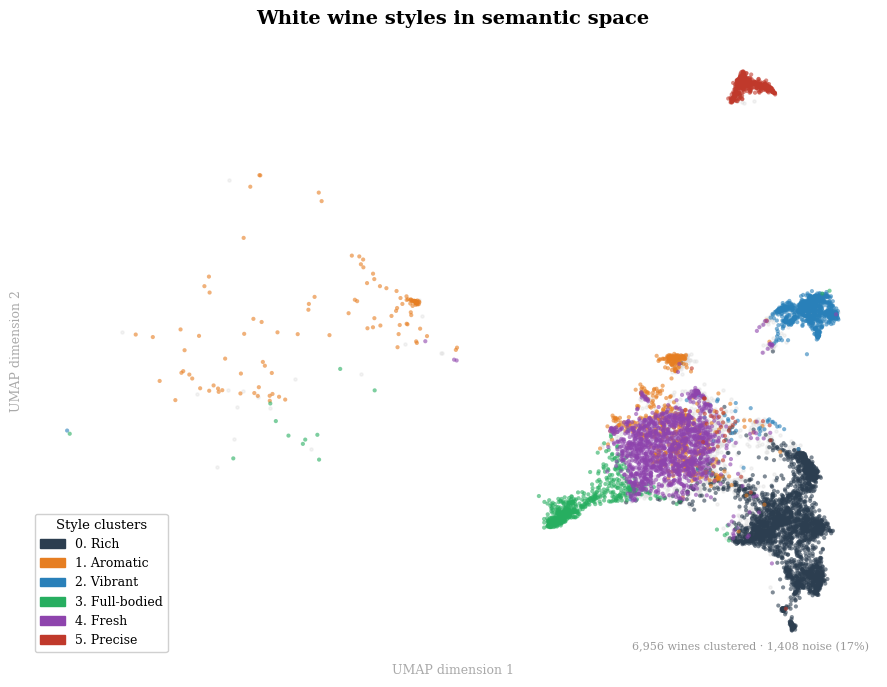

Saved: results/figures/04_umap_white.png


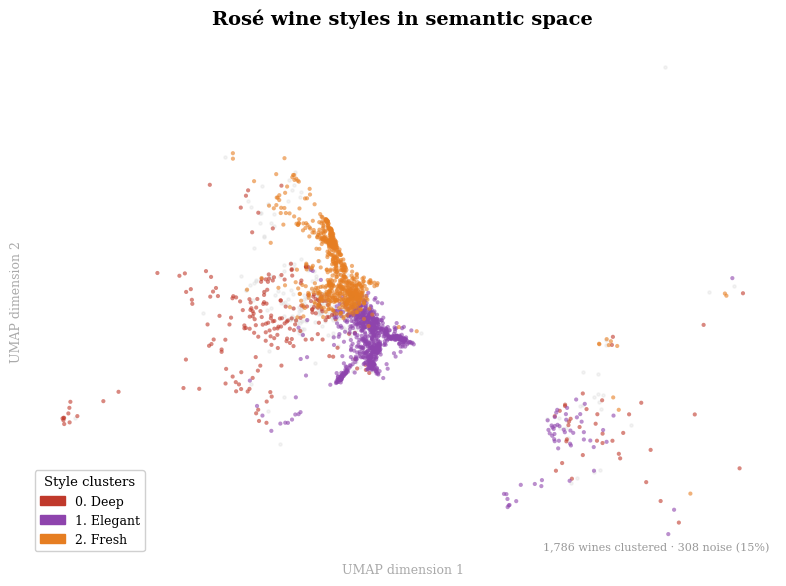

Saved: results/figures/04_umap_rose.png


In [38]:
def plot_umap_single(df, labels, short_labels, palette, title, fname, figsize=(9, 7)):
    fig, ax = plt.subplots(figsize=figsize)

    # Noise first (grey, behind clusters)
    noise = df['cluster'] == -1
    ax.scatter(df.loc[noise, 'umap_x'], df.loc[noise, 'umap_y'],
               c=NOISE_COLOR, s=5, alpha=0.35, rasterized=True, zorder=1)

    # Clusters
    handles = []
    for cluster_id, label in sorted(short_labels.items()):
        mask  = df['cluster'] == cluster_id
        color = palette[cluster_id % len(palette)]
        ax.scatter(df.loc[mask, 'umap_x'], df.loc[mask, 'umap_y'],
                   c=color, s=9, alpha=0.6, rasterized=True, zorder=2,
                   edgecolors='none')
        handles.append(mpatches.Patch(color=color, label=f'{cluster_id}. {label}'))

    ax.legend(handles=handles, loc='lower left', fontsize=9,
              frameon=True, framealpha=0.92, edgecolor='#ccc',
              title='Style clusters', title_fontsize=9.5)

    n_noise     = noise.sum()
    n_clustered = (~noise).sum()
    ax.set_title(title, fontsize=14, fontweight='bold', pad=14)
    ax.text(0.99, 0.01,
            f'{n_clustered:,} wines clustered · {n_noise:,} noise ({n_noise/(n_noise+n_clustered)*100:.0f}%)',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='#999')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('UMAP dimension 1', fontsize=9, color='#aaa')
    ax.set_ylabel('UMAP dimension 2', fontsize=9, color='#aaa')

    plt.tight_layout()
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')


plot_umap_single(df_red,   RED_LABELS,   RED_SHORT,   RED_PALETTE,
                 'Red wine styles in semantic space',
                 'results/figures/04_umap_red.png')

plot_umap_single(df_white, WHITE_LABELS, WHITE_SHORT, WHITE_PALETTE,
                 'White wine styles in semantic space',
                 'results/figures/04_umap_white.png')

plot_umap_single(df_rose,  ROSE_LABELS,  ROSE_SHORT,  ROSE_PALETTE,
                 'Rosé wine styles in semantic space',
                 'results/figures/04_umap_rose.png', figsize=(8, 6))


## 3. UMAP — combined overview

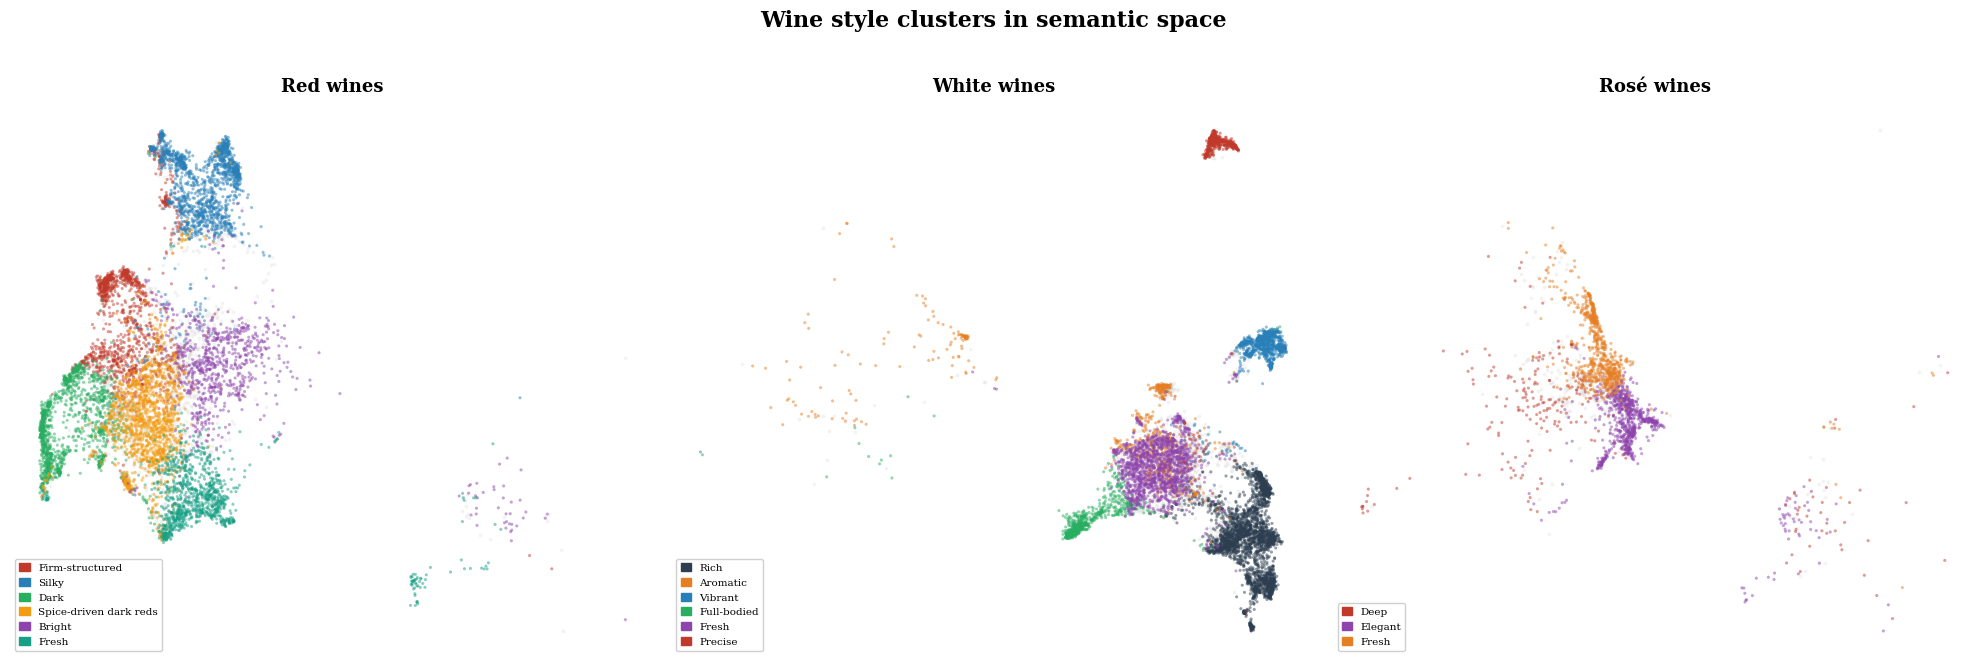

Saved: results/figures/04_umap_combined.png


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
fig.patch.set_facecolor('white')

configs = [
    (axes[0], df_red,   RED_SHORT,   RED_PALETTE,   'Red wines'),
    (axes[1], df_white, WHITE_SHORT, WHITE_PALETTE, 'White wines'),
    (axes[2], df_rose,  ROSE_SHORT,  ROSE_PALETTE,  'Rosé wines'),
]

for ax, df, short_labels, palette, title in configs:
    noise = df['cluster'] == -1
    ax.scatter(df.loc[noise, 'umap_x'], df.loc[noise, 'umap_y'],
               c=NOISE_COLOR, s=3, alpha=0.25, rasterized=True, zorder=1)

    handles = []
    for cluster_id, label in sorted(short_labels.items()):
        mask  = df['cluster'] == cluster_id
        color = palette[cluster_id % len(palette)]
        ax.scatter(df.loc[mask, 'umap_x'], df.loc[mask, 'umap_y'],
                   c=color, s=5, alpha=0.5, rasterized=True, zorder=2,
                   edgecolors='none')
        handles.append(mpatches.Patch(color=color, label=label))

    ax.legend(handles=handles, loc='lower left', fontsize=7.5,
              frameon=True, framealpha=0.92, edgecolor='#ccc',
              handlelength=1, handleheight=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('white')

plt.suptitle('Wine style clusters in semantic space',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/figures/04_umap_combined.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: results/figures/04_umap_combined.png')


## 4. TF-IDF top descriptors per cluster

Generic wine terms removed via custom stop word list.  
Remaining words are style-specific descriptors.

In [40]:
def get_tfidf_top_words(df, labels, n_words=10):
    text_col    = 'description_clean' if 'description_clean' in df.columns else 'description'
    cluster_ids = sorted(k for k in labels.keys())
    docs = [' '.join(df[df['cluster'] == cid][text_col].fillna('').tolist())
            for cid in cluster_ids]

    vec = TfidfVectorizer(
        max_features=5000,
        stop_words=STOP_WORDS,
        ngram_range=(1, 1),
        min_df=2,
        sublinear_tf=True,
        token_pattern=r'[a-zA-Zàâäéèêëîïôùûüÿçœæ]+',
    )
    tfidf = vec.fit_transform(docs)
    terms = vec.get_feature_names_out()

    result = {}
    for i, cid in enumerate(cluster_ids):
        row     = tfidf[i].toarray()[0]
        top_idx = row.argsort()[::-1][:n_words]
        result[cid] = [(terms[j], row[j]) for j in top_idx]
    return result


red_top   = get_tfidf_top_words(df_red,   RED_LABELS)
white_top = get_tfidf_top_words(df_white, WHITE_LABELS)
rose_top  = get_tfidf_top_words(df_rose,  ROSE_LABELS)

for name, top, labels in [('Red', red_top, RED_LABELS),
                           ('White', white_top, WHITE_LABELS),
                           ('Rosé', rose_top, ROSE_LABELS)]:
    print(f'\n{name}:')
    for cid, words in top.items():
        print(f'  {cid}: {labels[cid][:45]:45} | {", ".join(w for w, _ in words[:7])}')



Red:
  0: Firm-structured, floral reds with a savoury,  | cherry, gracious, spice, plum, padded, citrussy, youthfully
  1: Silky, red-fruited aromatics with forest floo | chicory, cherry, herbals, spice, savoury, fresh, bois
  2: Dark, oak-framed power reds built on cassis a | loamy, ironstone, cedar, spice, savoury, cherry, padrone
  3: Spice-driven dark reds, approachable and food | cherry, spice, fresh, plum, savoury, spicy, dried
  4: Bright, juicy, light reds with crunchy red fr | cherry, fresh, strawberry, spice, raspberry, light, plum
  5: Fresh, mineral, well-balanced reds with hones | fresh, freshness, oak, balanced, liquorice, actually, concentrated

White:
  0: Rich, mineral-driven whites with creamy orcha | lemon, cru, citrus, fresh, apple, domaine, rich
  1: Aromatic, fruit-expressive whites across the  | apple, fresh, orange, peach, apricot, citrus, pear
  2: Vibrant, tropical-citrus whites with herbal f | blackcurrant, lemon, citrus, fresh, lime, green, mineral
  3: Ful

## 5. TF-IDF word bars — one figure per colour

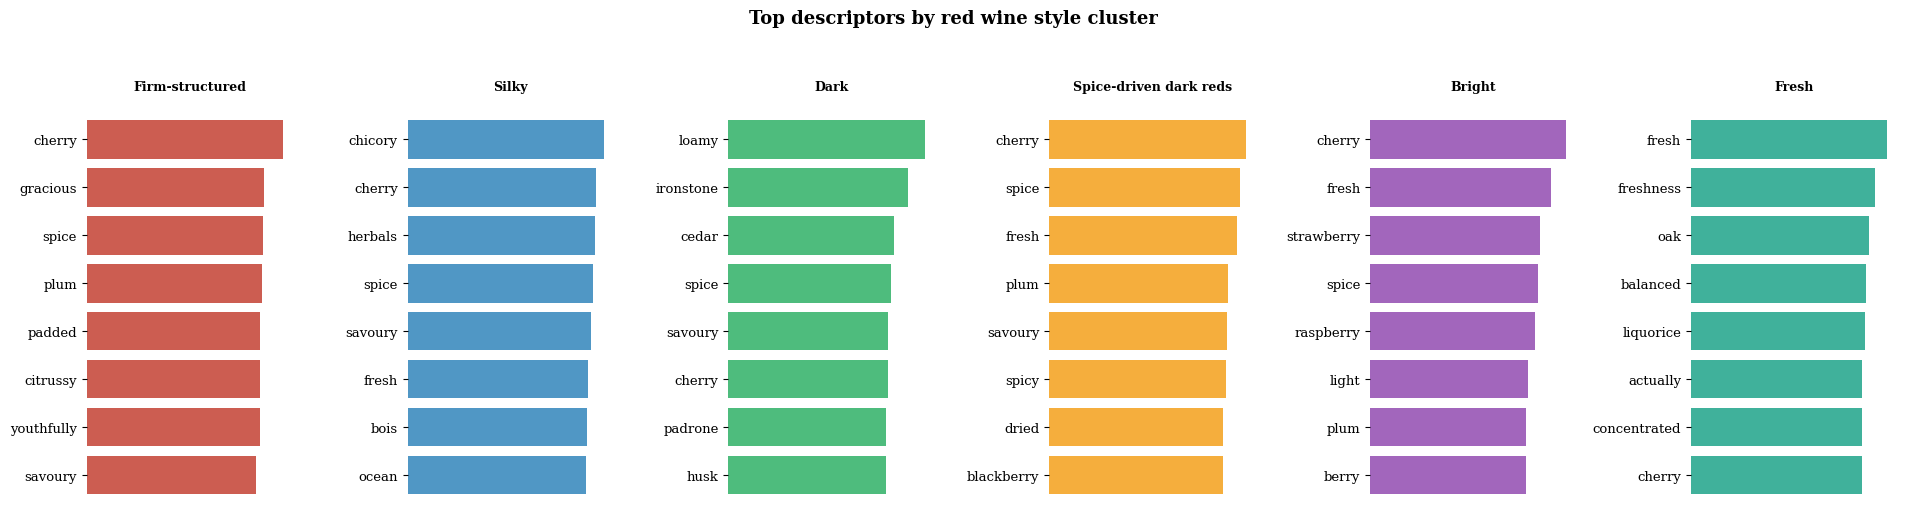

Saved: results/figures/04_tfidf_red.png


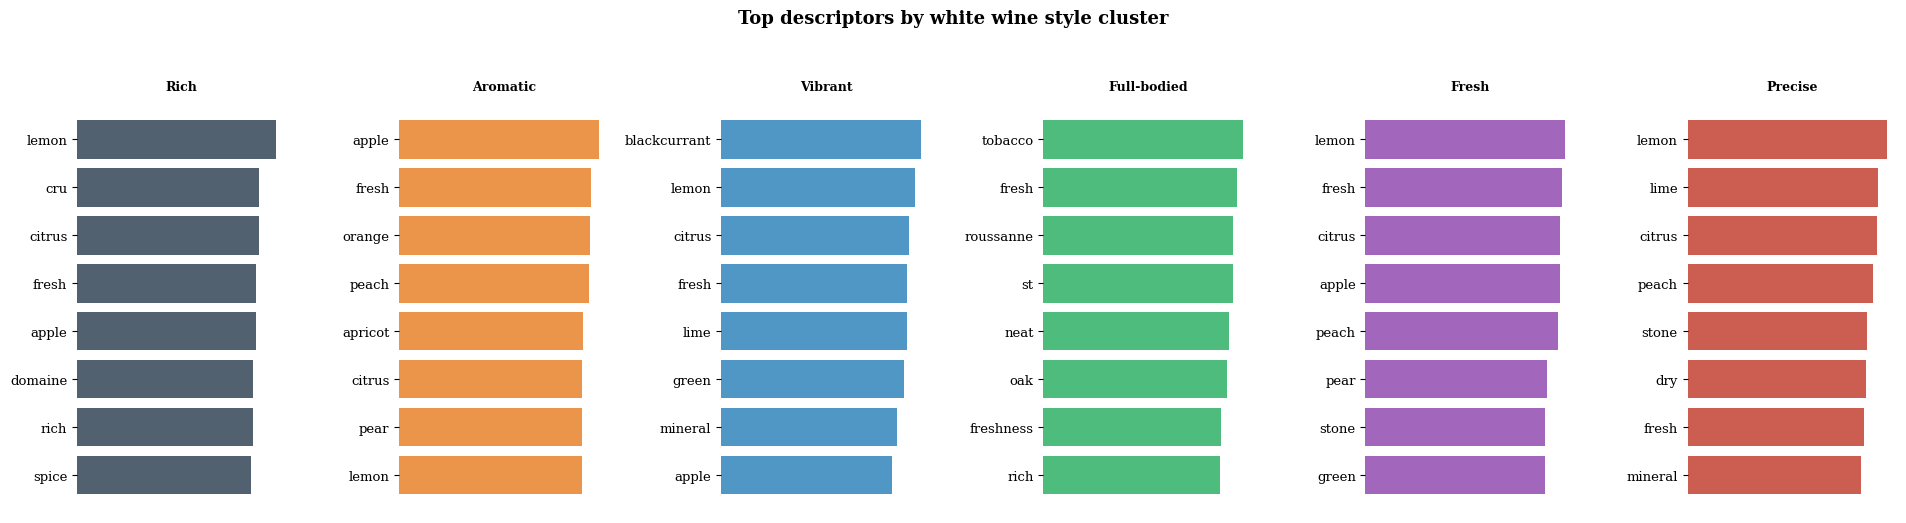

Saved: results/figures/04_tfidf_white.png


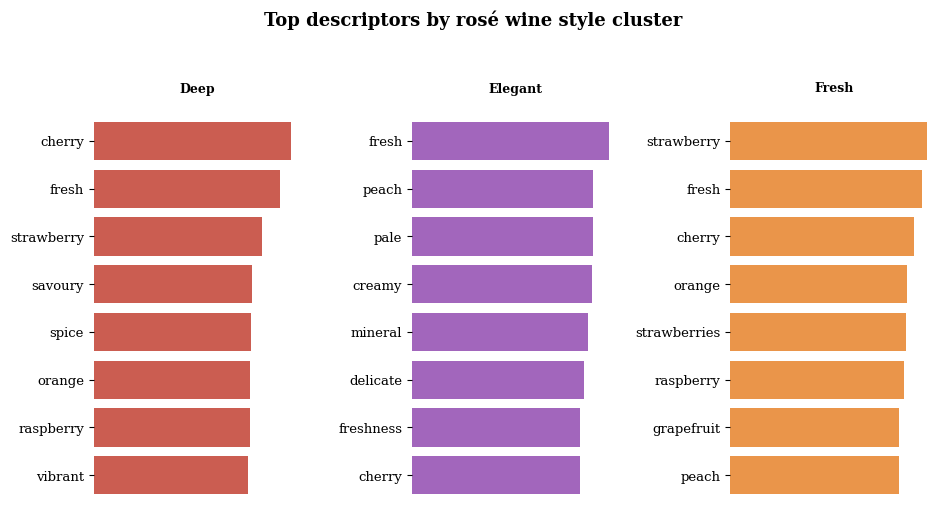

Saved: results/figures/04_tfidf_rose.png


In [41]:
def plot_tfidf_bars(top_words, labels, palette, title, fname, n_words=8):
    cluster_ids = sorted(labels.keys())
    n_clusters  = len(cluster_ids)
    fig, axes   = plt.subplots(1, n_clusters, figsize=(3.2 * n_clusters, 5))
    if n_clusters == 1:
        axes = [axes]

    for ax, cid in zip(axes, cluster_ids):
        words  = [w for w, _ in top_words[cid][:n_words]]
        scores = [s for _, s in top_words[cid][:n_words]]
        color  = palette[cid % len(palette)]

        ax.barh(range(n_words), scores[::-1], color=color, alpha=0.82)
        ax.set_yticks(range(n_words))
        ax.set_yticklabels(words[::-1], fontsize=9.5)
        ax.set_xticks([])
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        short = labels[cid].split(',')[0]
        ax.set_title(short, fontsize=9, fontweight='bold', pad=8)

    plt.suptitle(title, fontsize=13, fontweight='bold', y=1.04)
    plt.tight_layout()
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')


plot_tfidf_bars(red_top,   RED_LABELS,   RED_PALETTE,
                'Top descriptors by red wine style cluster',
                'results/figures/04_tfidf_red.png')

plot_tfidf_bars(white_top, WHITE_LABELS, WHITE_PALETTE,
                'Top descriptors by white wine style cluster',
                'results/figures/04_tfidf_white.png')

plot_tfidf_bars(rose_top,  ROSE_LABELS,  ROSE_PALETTE,
                'Top descriptors by rosé wine style cluster',
                'results/figures/04_tfidf_rose.png')


## 6. Cluster size comparison

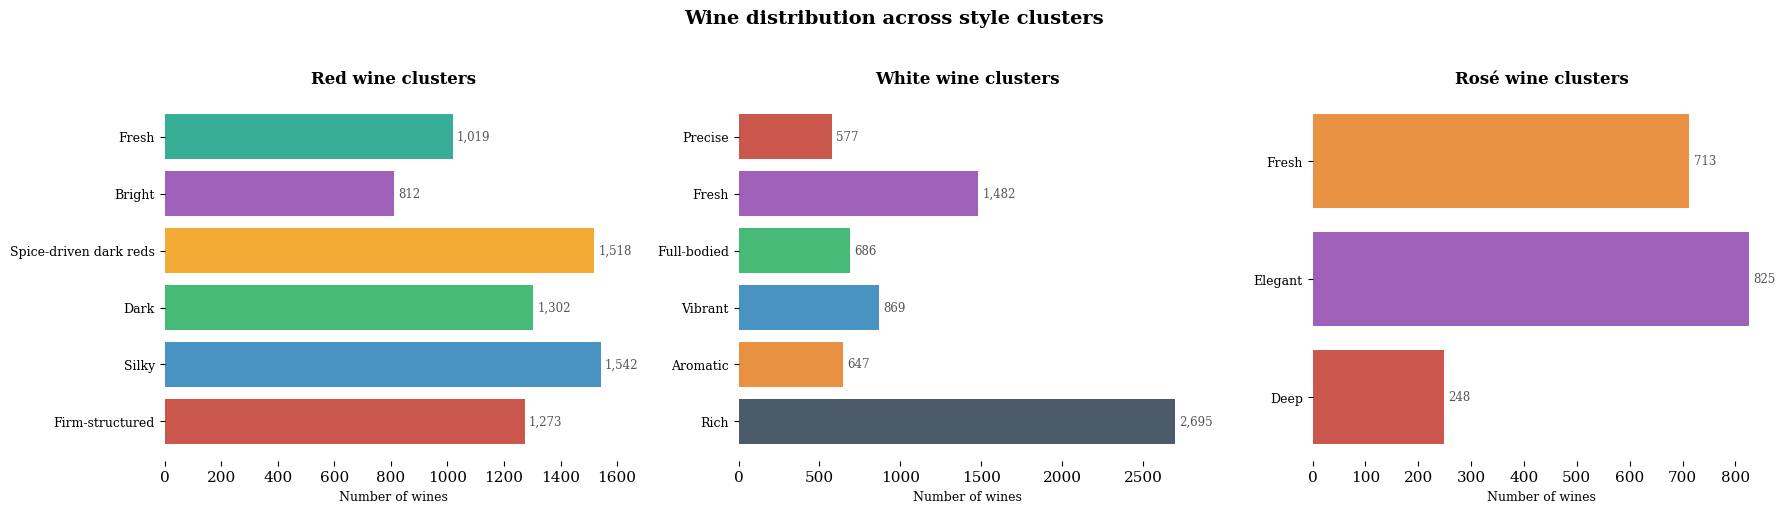

Saved: results/figures/04_cluster_sizes.png


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, df_c, labels, palette, title in [
    (axes[0], df_red,   RED_LABELS,   RED_PALETTE,   'Red wine clusters'),
    (axes[1], df_white, WHITE_LABELS, WHITE_PALETTE, 'White wine clusters'),
    (axes[2], df_rose,  ROSE_LABELS,  ROSE_PALETTE,  'Rosé wine clusters'),
]:
    cluster_ids = sorted(labels.keys())
    sizes  = [len(df_c[df_c['cluster'] == cid]) for cid in cluster_ids]
    colors = [palette[cid % len(palette)] for cid in cluster_ids]
    shorts = [labels[cid].split(',')[0] for cid in cluster_ids]

    bars = ax.barh(range(len(cluster_ids)), sizes, color=colors, alpha=0.85)
    ax.set_yticks(range(len(cluster_ids)))
    ax.set_yticklabels(shorts, fontsize=9)
    ax.set_xlabel('Number of wines', fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.spines['left'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar, size in zip(bars, sizes):
        ax.text(bar.get_width() + max(sizes) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{size:,}', va='center', fontsize=8.5, color='#555')

plt.suptitle('Wine distribution across style clusters',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/figures/04_cluster_sizes.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: results/figures/04_cluster_sizes.png')


---

## Summary

| Figure | Description | File |
|--------|-------------|------|
| UMAP Red | Red wine clusters in semantic space | `04_umap_red.png` |
| UMAP White | White wine clusters in semantic space | `04_umap_white.png` |
| UMAP Rosé | Rosé wine clusters in semantic space | `04_umap_rose.png` |
| UMAP Combined | All colours overview | `04_umap_combined.png` |
| TF-IDF Red | Style descriptors per red cluster | `04_tfidf_red.png` |
| TF-IDF White | Style descriptors per white cluster | `04_tfidf_white.png` |
| TF-IDF Rosé | Style descriptors per rosé cluster | `04_tfidf_rose.png` |
| Sizes | Cluster size comparison | `04_cluster_sizes.png` |

**Next:** article draft
